In [8]:
# ============================================================================
# BLOCK 1: IMPORTS, GLOBAL CONFIG & H100 OPTIMIZATIONS
# ============================================================================
import os
import gc
import random
import concurrent.futures
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
from scipy.signal import hilbert

# --- TỐI ƯU HÓA TUYỆT ĐỐI CHO H100 (HOPPER ARCHITECTURE) ---
if torch.cuda.is_available():
    # Kích hoạt TensorFloat-32 (TF32) - Tăng tốc 3-5 lần trên H100
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False
    print(f"🚀 Đã kích hoạt sức mạnh tối đa cho: {torch.cuda.get_device_name(0)}")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)
torch.manual_seed(SEED)           
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

plt.rcParams.update({
    "figure.dpi": 120, "font.size": 11, "axes.titlesize": 12, "axes.labelsize": 11,
    "xtick.labelsize": 10, "ytick.labelsize": 10, "axes.spines.top": False,
    "axes.spines.right": False, "axes.grid": True, "grid.alpha": 0.3, "legend.frameon": False,
})

🚀 Đã kích hoạt sức mạnh tối đa cho: NVIDIA H100 80GB HBM3


In [9]:
# ============================================================================
# BLOCK 2: CORE METRIC UTILITIES (PSI CALCULATIONS)
# ============================================================================
def dfa_hurst(x, min_win=16, max_win=None, n_win=10):
    x = np.asarray(x)
    N = x.size
    if N < 32: return 0.5
    if max_win is None: max_win = N // 4
    if max_win <= min_win: max_win = N // 2
    
    y = np.cumsum(x - x.mean())
    s_vals = np.unique(np.logspace(np.log10(min_win), np.log10(max_win), n_win, dtype=int))
    F = []
    
    for s in s_vals:
        if s < 4: continue
        n_segments = N // s
        if n_segments < 2: continue
        rms = []
        for i in range(n_segments):
            seg = y[i * s : (i + 1) * s]
            t = np.arange(s)
            p = np.polyfit(t, seg, 1)
            trend = np.polyval(p, t)
            detrended = seg - trend
            rms.append(np.sqrt(np.mean(detrended**2)))
        if rms: F.append(np.mean(rms))
        
    F = np.array(F)
    if len(F) < 2: return 0.5
    coeffs = np.polyfit(np.log(s_vals[: len(F)]), np.log(F), 1)
    return float(coeffs[0])

def compute_raw_metrics(X, Hopt=0.7, sigma_H=0.15):
    C, T = X.shape
    H_vals = [dfa_hurst(X[ch]) if X.shape[1] >= 32 else 0.5 for ch in range(C)]
    H_raw = float(np.mean(H_vals))
    Heff = np.exp(-((H_raw - Hopt) ** 2) / (2.0 * sigma_H**2))

    X_centered = X - np.mean(X, axis=1, keepdims=True)
    analytic_signal = hilbert(X_centered, axis=-1)
    phases = np.angle(analytic_signal)
    
    R_t = np.abs(np.mean(np.exp(1j * phases), axis=0))
    M = float(np.std(R_t))

    return {"H_raw": H_raw, "Heff": Heff, "M": M}

In [10]:
# ============================================================================
# BLOCK 3: MULTISCALE ACTIVATIONS & ADAPTER
# ============================================================================
def gather_multiscale_activations(activations_dict, samples_per_layer=32):
    collected_features = []
    layers = ['layer1', 'layer2', 'layer3', 'layer4']
    
    for layer_name in layers:
        if layer_name not in activations_dict: continue
        act = activations_dict[layer_name]
        
        if len(act.shape) > 2: act = torch.mean(act, dim=[2, 3]) 
        n_channels = act.shape[1]
        
        if n_channels >= samples_per_layer:
            idx = torch.randperm(n_channels, device=act.device)[:samples_per_layer]
            act = act[:, idx]
            
        collected_features.append(act)
    
    if not collected_features: return None
    return torch.cat(collected_features, dim=1)

def prepare_cnn_activations(activations, labels, smooth_window=5):
    data = activations.detach().cpu().numpy() if isinstance(activations, torch.Tensor) else activations
    lbls = labels.detach().cpu().numpy() if isinstance(labels, torch.Tensor) else labels
    
    sort_idx = np.argsort(lbls)
    data_sorted = data[sort_idx]
    
    df_temp = pd.DataFrame(data_sorted)
    df_temp['label'] = lbls[sort_idx]
    data_detrended = df_temp.groupby('label').transform(lambda x: x - x.mean()).values
    
    data_smoothed = pd.DataFrame(data_detrended).rolling(
        window=smooth_window, center=True, min_periods=1
    ).mean().values
    
    return data_smoothed.T

In [11]:
# ============================================================================
# BLOCK 4: EXPERIMENT SUMMARIZATION & PLOTTING
# ============================================================================
def summarize_experiment_results(experiment_log):
    df = pd.DataFrame(experiment_log)
    mu_H = df['Heff'].mean()
    std_H = df['Heff'].std() if df['Heff'].std() > 0 else 1e-9
    mu_M = df['M'].mean()
    std_M = df['M'].std() if df['M'].std() > 0 else 1e-9
    
    df['Hz'] = (df['Heff'] - mu_H) / std_H
    df['Mz'] = (df['M'] - mu_M) / std_M
    df['Psi'] = 0.5 * df['Hz'] + 0.5 * df['Mz']
    return df

def plot_final_report(df):
    plt.rcParams.update({'font.size': 11})
    fig, ax1 = plt.subplots(figsize=(12, 5))

    color_acc = '#1f77b4' 
    ax1.set_xlabel('Epochs', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Validation Accuracy (%)', color=color_acc, fontsize=12, fontweight='bold')
    line1, = ax1.plot(df['epoch'], df['val_acc'], color=color_acc, linewidth=2.5, label='Accuracy', marker='o', markersize=3, alpha=0.9)
    ax1.tick_params(axis='y', labelcolor=color_acc)

    ax2 = ax1.twinx()
    color_psi = '#d62728' 
    ax2.set_ylabel('Consciousness Index ($\\Psi$)', color=color_psi, fontsize=12, fontweight='bold')
    line2, = ax2.plot(df['epoch'], df['Psi'], color=color_psi, linewidth=2, linestyle='--', label='$\\Psi$ Index (Z-scored)', marker='s', markersize=3)
    ax2.tick_params(axis='y', labelcolor=color_psi)

    ax3 = ax1.twinx()
    color_loss = '#2ca02c' 
    ax3.spines["right"].set_position(("axes", 1.08)) 
    ax3.spines["right"].set_visible(True)
    ax3.set_ylabel('Validation Loss', color=color_loss, fontsize=11, fontweight='bold')
    line3, = ax3.plot(df['epoch'], df['val_loss'], color=color_loss, linewidth=1.5, linestyle=':', label='Val Loss', alpha=0.8)
    ax3.tick_params(axis='y', labelcolor=color_loss)

    best_idx = df['val_loss'].idxmin()
    best_epoch = df.loc[best_idx, 'epoch']
    plt.axvline(x=best_epoch, color='gray', linestyle='-.', alpha=0.5, linewidth=1)
    
    ylim_min, ylim_max = ax1.get_ylim()
    ax1.text(best_epoch, ylim_min + (ylim_max - ylim_min) * 0.1, f'  Optimal (Ep {int(best_epoch)})', color='#444', fontsize=9, rotation=90, verticalalignment='bottom')

    lines = [line1, line2, line3]
    ax1.legend(lines, [l.get_label() for l in lines], loc='lower right', bbox_to_anchor=(0.95, 0.05), fancybox=True, framealpha=0.9, shadow=True, fontsize=10)
    plt.title('Dynamics of Consciousness ($\\Psi$) vs Generalization Performance', fontsize=14, pad=10)
    plt.subplots_adjust(top=0.92, bottom=0.10, left=0.08, right=0.88)
    plt.show()

In [12]:
# ============================================================================
# BLOCK 5: HIGH-PERFORMANCE DATA PIPELINE (MULTI-CHUNK DATASET SUPPORT)
# ============================================================================
class FastImageFolder(Dataset):
    def __init__(self, roots, transform=None):
        # Hỗ trợ nhận vào 1 thư mục (chuỗi) hoặc nhiều thư mục (list)
        if isinstance(roots, str):
            roots = [roots]
        self.roots = roots
        self.transform = transform
        self.samples, self.class_to_idx = self._parallel_scan(roots)

    def _parallel_scan(self, root_dirs):
        # 1. Tìm TẤT CẢ các class có mặt trong mọi thư mục root
        all_classes = set()
        for r in root_dirs:
            if os.path.isdir(r):
                all_classes.update([d.name for d in os.scandir(r) if d.is_dir()])
        
        # 2. Sắp xếp Alphabet để map index đồng nhất
        classes = sorted(list(all_classes))
        class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
        samples = []
        
        # 3. Hàm quét 1 class xuyên qua nhiều thư mục root
        def scan_single_class(cls_name):
            cls_idx = class_to_idx[cls_name]
            cls_samples = []
            for r in root_dirs:
                cls_dir = os.path.join(r, cls_name)
                # Nếu class này tồn tại trong chunk này thì lấy ảnh
                if os.path.exists(cls_dir) and os.path.isdir(cls_dir):
                    cls_samples.extend([
                        (entry.path, cls_idx) 
                        for entry in os.scandir(cls_dir) 
                        if entry.is_file() and entry.name.lower().endswith(('.png', '.jpg', '.jpeg'))
                    ])
            return cls_samples

        # Dùng 32 luồng quét đồng loạt các chunks
        with concurrent.futures.ThreadPoolExecutor(max_workers=32) as executor:
            for res in executor.map(scan_single_class, classes): 
                samples.extend(res)
                
        print(f"🎯 Quét xong! Đã gộp {len(root_dirs)} thư mục. Tìm thấy {len(samples)} ảnh trong {len(classes)} classes.")
        return samples, class_to_idx

    def __len__(self): 
        return len(self.samples)
    
    def __getitem__(self, idx):
        path, target = self.samples[idx]
        img = Image.open(path).convert('RGB')
        if self.transform: img = self.transform(img)
        return img, target
        
def get_imagenet_loaders(data_dir, train_batch, val_batch):
    print(f"Initializing Multi-Chunk Loaders & Auto-detecting classes...")
    train_transform = transforms.Compose([
        transforms.RandomResizedCrop(224), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])
    val_transform = transforms.Compose([
        transforms.Resize(256), transforms.CenterCrop(224),
        transforms.ToTensor(), transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
    ])

    # 🔴 TỰ ĐỘNG TÌM TẤT CẢ CÁC THƯ MỤC BẮT ĐẦU BẰNG "train." VÀ "val."
    train_dirs = [os.path.join(data_dir, d) for d in os.listdir(data_dir) if d.startswith('train') and os.path.isdir(os.path.join(data_dir, d))]
    val_dirs = [os.path.join(data_dir, d) for d in os.listdir(data_dir) if d.startswith('val') and os.path.isdir(os.path.join(data_dir, d))]
    
    print(f"📦 Phát hiện các chunks Train: {[os.path.basename(d) for d in train_dirs]}")
    print(f"📦 Phát hiện các chunks Val: {[os.path.basename(d) for d in val_dirs]}")
    
    # Truyền nguyên cái List thư mục vào class
    train_dataset = FastImageFolder(train_dirs, transform=train_transform)
    val_dataset = FastImageFolder(val_dirs, transform=val_transform)
    
    detected_classes = len(train_dataset.class_to_idx)
    print(f"✅ Auto-detected {detected_classes} classes from chunked structure!")
    
    trainloader = DataLoader(train_dataset, batch_size=train_batch, shuffle=True, 
                             num_workers=8, pin_memory=True, persistent_workers=True)
    valloader = DataLoader(val_dataset, batch_size=val_batch, shuffle=False, 
                           num_workers=8, pin_memory=True, persistent_workers=True)
    
    return trainloader, valloader, detected_classes

In [13]:
# ============================================================================
# BLOCK 6: MODEL INITIALIZATION & CALLBACKS (ViT - PRETRAINED)
# ============================================================================
class EarlyStopping:
    def __init__(self, patience=7, delta=0, path='best_vit_pretrained.pt'):
        self.patience = patience
        self.delta = delta
        self.path = path
        self.counter = 0
        self.best_score = None
        self.early_stop = False
        self.val_loss_min = np.inf

    def __call__(self, val_loss, model):
        score = -val_loss
        if self.best_score is None:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
        elif score < self.best_score + self.delta:
            self.counter += 1
            if self.counter >= self.patience: self.early_stop = True
        else:
            self.best_score = score
            self.save_checkpoint(val_loss, model)
            self.counter = 0

    def save_checkpoint(self, val_loss, model):
        torch.save(model.state_dict(), self.path)
        self.val_loss_min = val_loss

def get_vit_classifier(num_classes=100):
    print("Khởi tạo Vision Transformer (ViT-Base-16) với TRỌNG SỐ PRE-TRAIN...")
    
    # weights='DEFAULT' sẽ tự động tải bộ não đã được huấn luyện trên ImageNet-1K
    model = models.vit_b_16(weights='DEFAULT')
    
    # Đóng băng (Freeze) các lớp dưới nếu muốn train cực nhanh, nhưng ở đây có H100 
    # nên ta thả rông để Fine-tune toàn bộ mạng (End-to-End) luôn cho độ chính xác cao nhất.
    
    # Chỉ thay đổi đầu ra lớp cuối cùng cho khớp số class của dataset
    in_features = model.heads.head.in_features
    model.heads.head = nn.Linear(in_features, num_classes)
    
    return model

def setup_vit_hooks(model):
    """
    Hook chính xác vào các Block {1, 4, 7, 10} theo Algorithm 1 của bài báo.
    Tương ứng với index {0, 3, 6, 9} trong cấu trúc list của PyTorch.
    """
    activations = {}
    
    def get_activation(name):
        def hook(module, input, output):
            # Lấy trung bình (mean) của 197 tokens để ra vector 768 chiều
            act = output.mean(dim=1)
            activations[name] = act.detach()
        return hook

    layers = model.encoder.layers
    
    layers[0].register_forward_hook(get_activation('layer1'))  # Block 1
    layers[3].register_forward_hook(get_activation('layer2'))  # Block 4
    layers[6].register_forward_hook(get_activation('layer3'))  # Block 7
    layers[9].register_forward_hook(get_activation('layer4'))  # Block 10

    return activations

Initializing Multi-Chunk Loaders & Auto-detecting classes...
📦 Phát hiện các chunks Train: ['train.X1', 'train.X3', 'train.X4', 'train.X2']
📦 Phát hiện các chunks Val: ['val.X']
🎯 Quét xong! Đã gộp 4 thư mục. Tìm thấy 130000 ảnh trong 100 classes.
🎯 Quét xong! Đã gộp 1 thư mục. Tìm thấy 5000 ảnh trong 100 classes.
✅ Auto-detected 100 classes from chunked structure!
Khởi tạo Vision Transformer (ViT-Base-16) với TRỌNG SỐ PRE-TRAIN...
🚀 ViT Fine-tuning started for max 5 epochs (Batch: 256)...
   [Epoch 1] Đang xử lý Train Batch 20/508...
   [Epoch 1] Đang xử lý Train Batch 40/508...
   [Epoch 1] Đang xử lý Train Batch 60/508...
   [Epoch 1] Đang xử lý Train Batch 80/508...
   [Epoch 1] Đang xử lý Train Batch 100/508...
   [Epoch 1] Đang xử lý Train Batch 120/508...
   [Epoch 1] Đang xử lý Train Batch 140/508...
   [Epoch 1] Đang xử lý Train Batch 160/508...
   [Epoch 1] Đang xử lý Train Batch 180/508...
   [Epoch 1] Đang xử lý Train Batch 200/508...
   [Epoch 1] Đang xử lý Train Batch 220

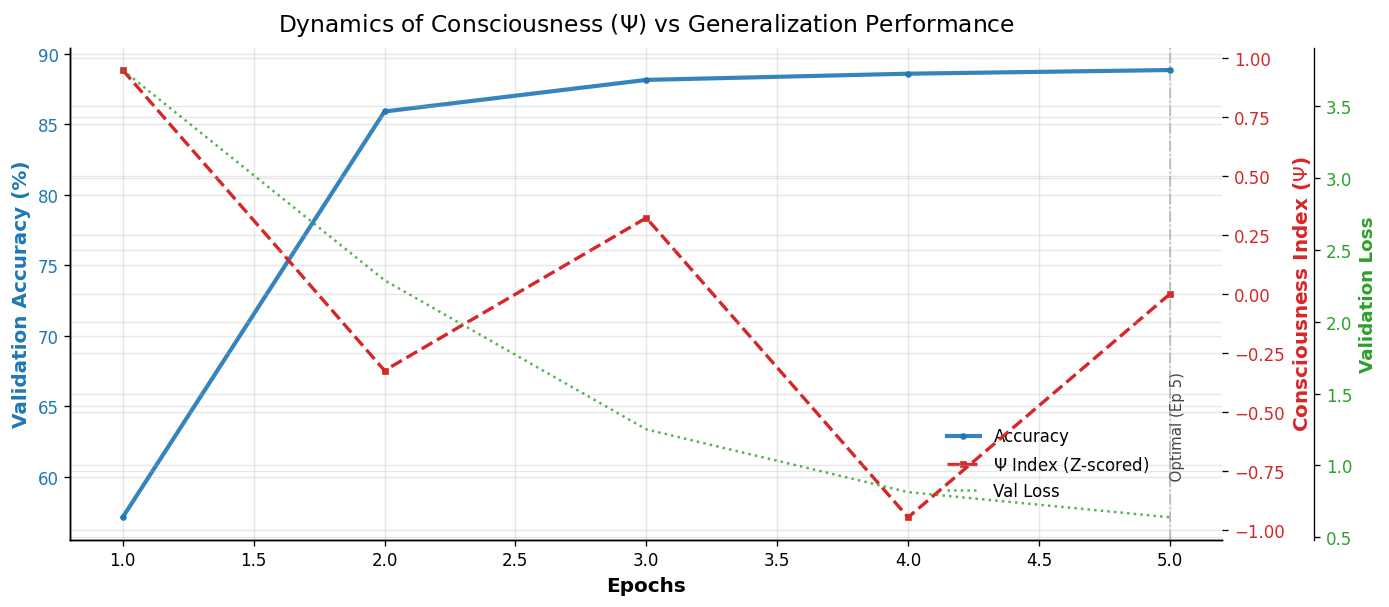

In [14]:
# ============================================================================
# BLOCK 7: MAIN EXECUTION (ViT PRE-TRAINED FINE-TUNING)
# ============================================================================
if __name__ == "__main__":
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()

    DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Đường dẫn thư mục chứa ảnh (Nếu đang dùng ổ /tmp siêu tốc)
    IMAGENET_PATH = "/kaggle/input/datasets/ambityga/imagenet100" 
    
    # ViT khá to nên Batch Size 256 là mức an toàn, tối ưu cho H100
    VAL_BATCH_SIZE = 256   
    TRAIN_BATCH_SIZE = 256 
    EPOCHS = 5            # Pre-train hội tụ rất nhanh, 30 epoch là quá đủ
    PATIENCE = 7         
    LR = 1e-4              

    trainloader, valloader, NUM_CLASSES = get_imagenet_loaders(IMAGENET_PATH, TRAIN_BATCH_SIZE, VAL_BATCH_SIZE)

    # 1. Khởi tạo mô hình (Đã tự động load Pre-trained weights bên trong)
    model = get_vit_classifier(num_classes=NUM_CLASSES).to(DEVICE)
    
    # 2. Setup SGD (Giống hệt YOLO) và KHÔNG dùng Scheduler
    criterion = nn.CrossEntropyLoss()
    
    # Dùng SGD với Momentum 0.9 để mạng học ổn định hơn
    optimizer = optim.SGD(model.parameters(), lr=LR, momentum=0.9, weight_decay=1e-4) 
    
    early_stopping = EarlyStopping(patience=PATIENCE, path='best_vit_pretrained.pt')
    
    scaler = torch.amp.GradScaler('cuda')
    activations = setup_vit_hooks(model)

    history = []
    print(f"🚀 ViT Fine-tuning started for max {EPOCHS} epochs (Batch: {TRAIN_BATCH_SIZE})...")

    for epoch in range(EPOCHS):
        # --- TRAIN ---
        model.train()
        train_loss, correct, total = 0, 0, 0
        
        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True) 
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            # ViT học nhanh nên in log mỗi 20 batch
            if (batch_idx + 1) % 20 == 0:
                print(f"   [Epoch {epoch+1}] Đang xử lý Train Batch {batch_idx+1}/{len(trainloader)}...")
        
        avg_train_loss = train_loss / len(trainloader)
        train_acc = 100. * correct / total

        # --- VALIDATE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for batch_idx, (inputs, targets) in enumerate(valloader): 
                inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        avg_val_loss = val_loss / len(valloader)
        val_acc = 100. * val_correct / val_total 

        # --- TÍNH PSI ĐA TẦNG ---
        data_iter = iter(valloader)
        inputs_psi, targets_psi = next(data_iter)
        inputs_psi = inputs_psi.to(DEVICE)
        
        with torch.no_grad():
            with torch.amp.autocast(device_type='cuda'): _ = model(inputs_psi) 
        
        multiscale_matrix = gather_multiscale_activations(activations, samples_per_layer=32)
        cnn_signals = prepare_cnn_activations(multiscale_matrix, targets_psi.cpu().numpy(), smooth_window=5)
        metrics = compute_raw_metrics(cnn_signals)

        log = {
            "epoch": epoch + 1, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
            "val_acc": val_acc, "Heff": metrics["Heff"], "M": metrics["M"], "H_raw": metrics["H_raw"] 
        }
        history.append(log)
        
        # In kết quả của Epoch
        print(f"Ep {epoch+1:03d} | Train Acc: {train_acc:.2f}% | Val Loss:{avg_val_loss:.3f} | Val Acc:{val_acc:.2f}% | Heff:{metrics['Heff']:.2f} | M:{metrics['M']:.3f} | LR:{optimizer.param_groups[0]['lr']:.6f}")

        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"🛑 Early stopping triggered at epoch {epoch+1}")
            break

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    print("\n✅ Quá trình Fine-tune ViT hoàn tất. Tính toán Z-score cho Psi...")
    df_results = summarize_experiment_results(history) 

    print("\n" + "="*60)
    for _, row in df_results.iterrows():
        print(f"Epoch {int(row['epoch']):<3d} | Acc: {row['val_acc']:<6.2f} | Hz: {row['Hz']:<6.3f} | Mz: {row['Mz']:<6.3f} | Psi: {row['Psi']:<7.4f}")
              
    df_results.to_csv("final_results_vit_pretrained.csv", index=False)
    plot_final_report(df_results)

🔄 BẮT ĐẦU BLOCK 8: HUẤN LUYỆN TIẾP NỐI (ViT PRE-TRAINED)
✅ Đã tải thành công lịch sử cũ: 5 epochs.
Khởi tạo Vision Transformer (ViT-Base-16) với TRỌNG SỐ PRE-TRAIN...
✅ Đã nạp thành công bộ não ViT xuất sắc nhất từ: best_vit_pretrained.pt

🚀 TIẾP TỤC TRAIN TỪ EPOCH 6 ĐẾN 15...
   [Epoch 6] Đang xử lý Train Batch 20/508...
   [Epoch 6] Đang xử lý Train Batch 40/508...
   [Epoch 6] Đang xử lý Train Batch 60/508...
   [Epoch 6] Đang xử lý Train Batch 80/508...
   [Epoch 6] Đang xử lý Train Batch 100/508...
   [Epoch 6] Đang xử lý Train Batch 120/508...
   [Epoch 6] Đang xử lý Train Batch 140/508...
   [Epoch 6] Đang xử lý Train Batch 160/508...
   [Epoch 6] Đang xử lý Train Batch 180/508...
   [Epoch 6] Đang xử lý Train Batch 200/508...
   [Epoch 6] Đang xử lý Train Batch 220/508...
   [Epoch 6] Đang xử lý Train Batch 240/508...
   [Epoch 6] Đang xử lý Train Batch 260/508...
   [Epoch 6] Đang xử lý Train Batch 280/508...
   [Epoch 6] Đang xử lý Train Batch 300/508...
   [Epoch 6] Đang xử 

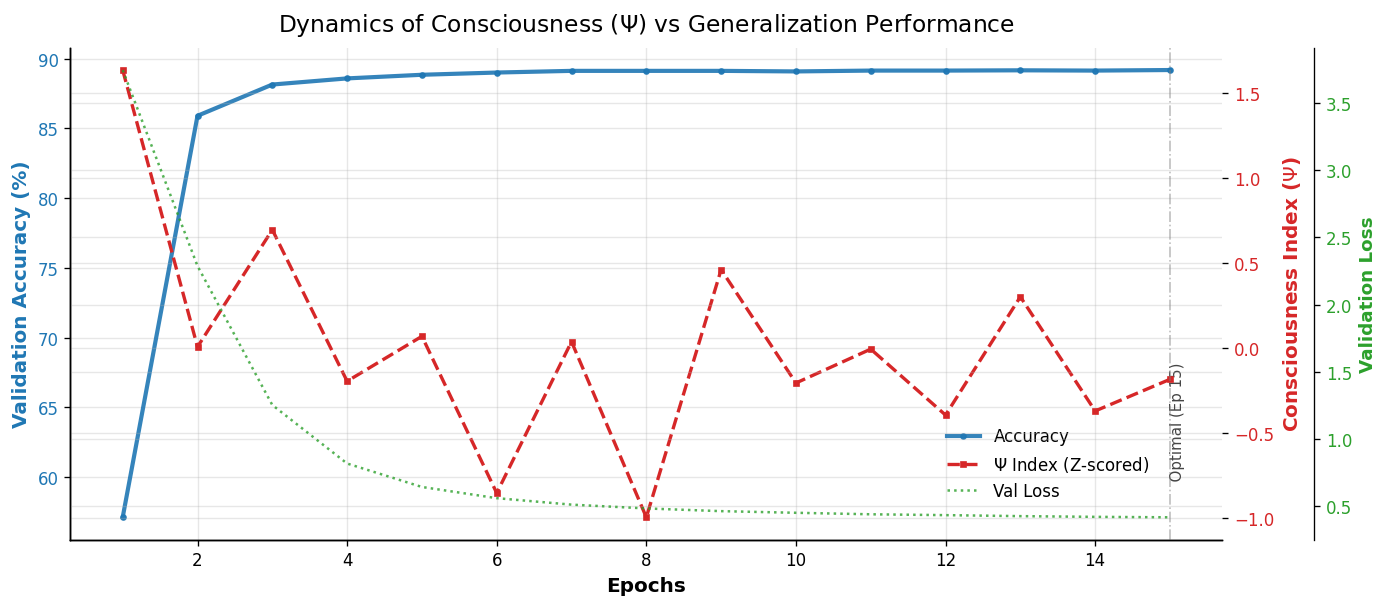

In [15]:
if __name__ == "__main__":
    print("🔄 BẮT ĐẦU BLOCK 8: HUẤN LUYỆN TIẾP NỐI (ViT PRE-TRAINED)")
    
    # --- CẤU HÌNH CHO GIAI ĐOẠN 2 ---
    ADDITIONAL_EPOCHS = 10     # Số epoch bạn muốn chạy thêm (ví dụ: 10)
    LR_RESUME = 1e-4           # Giữ nguyên LR cố định giống y hệt Block 7
    PATIENCE = 7
    
    checkpoint_path = 'best_vit_pretrained.pt'
    csv_path = 'final_results_vit_pretrained.csv'
    
    # 1. KHÔI PHỤC LỊCH SỬ TỪ FILE CSV CŨ
    history = []
    start_epoch = 0
    best_old_val_loss = float('inf')
    
    if os.path.exists(csv_path):
        old_df = pd.read_csv(csv_path)
        for _, row in old_df.iterrows():
            history.append({
                "epoch": int(row["epoch"]),
                "train_loss": float(row["train_loss"]),
                "val_loss": float(row["val_loss"]),
                "val_acc": float(row["val_acc"]),
                "Heff": float(row["Heff"]),
                "M": float(row["M"]),
                "H_raw": float(row.get("H_raw", 0.5))
            })
        start_epoch = int(old_df["epoch"].max())
        best_old_val_loss = old_df["val_loss"].min()
        print(f"✅ Đã tải thành công lịch sử cũ: {start_epoch} epochs.")
    else:
        print("⚠️ Không tìm thấy file CSV cũ. Sẽ chỉ ghi nhận từ Epoch hiện tại.")

    # Đảm bảo Dataset đã được nạp (Sử dụng lại loaders từ Block 7)
    try:
        trainloader
    except NameError:
        print("⚠️ Đang nạp lại Dataset Loaders...")
        IMAGENET_PATH = "/tmp/imagenet-fast" # Hoặc đường dẫn Kaggle của bạn
        trainloader, valloader, NUM_CLASSES = get_imagenet_loaders(IMAGENET_PATH, 256, 256)

    # 2. KHỞI TẠO MODEL VÀ NẠP TRỌNG SỐ
    model = get_vit_classifier(num_classes=NUM_CLASSES).to(DEVICE)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        print(f"✅ Đã nạp thành công bộ não ViT xuất sắc nhất từ: {checkpoint_path}")
    else:
        print("⚠️ CẢNH BÁO: Không tìm thấy file trọng số, mô hình sẽ học lại từ đầu!")

    # 3. SETUP OPTIMIZER CHUẨN SGD CỐ ĐỊNH (KHÔNG SCHEDULER)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR_RESUME, momentum=0.9, weight_decay=1e-4) 
    
    # Kế thừa mức Val Loss tốt nhất để EarlyStopping không bị đếm lại từ đầu
    early_stopping = EarlyStopping(patience=PATIENCE, path=checkpoint_path)
    if best_old_val_loss != float('inf'):
        early_stopping.best_score = -best_old_val_loss
        early_stopping.val_loss_min = best_old_val_loss

    scaler = torch.amp.GradScaler('cuda')
    activations = setup_vit_hooks(model)

    print(f"\n🚀 TIẾP TỤC TRAIN TỪ EPOCH {start_epoch + 1} ĐẾN {start_epoch + ADDITIONAL_EPOCHS}...")

    # 4. VÒNG LẶP HUẤN LUYỆN
    for epoch in range(start_epoch, start_epoch + ADDITIONAL_EPOCHS):
        current_ep = epoch + 1
        
        # --- TRAIN ---
        model.train()
        train_loss, correct, total = 0, 0, 0
        
        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True) 
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            if (batch_idx + 1) % 20 == 0:
                print(f"   [Epoch {current_ep}] Đang xử lý Train Batch {batch_idx+1}/{len(trainloader)}...")
        
        avg_train_loss = train_loss / len(trainloader)
        train_acc = 100. * correct / total

        # --- VALIDATE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for inputs, targets in valloader: 
                inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        avg_val_loss = val_loss / len(valloader)
        val_acc = 100. * val_correct / val_total

        # --- TÍNH PSI ĐA TẦNG ---
        data_iter = iter(valloader)
        inputs_psi, targets_psi = next(data_iter)
        inputs_psi = inputs_psi.to(DEVICE)
        
        with torch.no_grad():
            with torch.amp.autocast(device_type='cuda'): _ = model(inputs_psi) 
        
        multiscale_matrix = gather_multiscale_activations(activations, samples_per_layer=32)
        cnn_signals = prepare_cnn_activations(multiscale_matrix, targets_psi.cpu().numpy(), smooth_window=5)
        metrics = compute_raw_metrics(cnn_signals)

        log = {
            "epoch": current_ep, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
            "val_acc": val_acc, "Heff": metrics["Heff"], "M": metrics["M"], "H_raw": metrics["H_raw"] 
        }
        history.append(log)
        print(f"Ep {current_ep:03d} | Train Acc: {train_acc:.2f}% | Val Loss:{avg_val_loss:.3f} | Val Acc:{val_acc:.2f}% | Heff:{metrics['Heff']:.2f} | M:{metrics['M']:.3f} | LR:{optimizer.param_groups[0]['lr']:.6f}")

        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"🛑 Early stopping triggered at epoch {current_ep}")
            break

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # 5. TỔNG HỢP VÀ VẼ LẠI BIỂU ĐỒ (Bao gồm cả 5 epoch cũ và các epoch mới)
    print("\n✅ Training Finished. Calculating Standardized Psi (Z-score) for ALL epochs...")
    df_results = summarize_experiment_results(history) 

    print("\n" + "="*60)
    # In toàn bộ lịch sử
    for _, row in df_results.iterrows():
        print(f"Epoch {int(row['epoch']):<3d} | Acc: {row['val_acc']:<6.2f} | Hz: {row['Hz']:<6.3f} | Mz: {row['Mz']:<6.3f} | Psi: {row['Psi']:<7.4f}")
              
    # Ghi đè file CSV để lưu lại toàn bộ lịch sử nối dài
    df_results.to_csv(csv_path, index=False)
    
    # Vẽ biểu đồ tổng kết liền mạch
    plot_final_report(df_results)

🔄 BẮT ĐẦU BLOCK 8: HUẤN LUYỆN TIẾP NỐI (ViT PRE-TRAINED)
✅ Đã tải thành công lịch sử cũ: 15 epochs.
Khởi tạo Vision Transformer (ViT-Base-16) với TRỌNG SỐ PRE-TRAIN...
✅ Đã nạp thành công bộ não ViT xuất sắc nhất từ: best_vit_pretrained.pt

🚀 TIẾP TỤC TRAIN TỪ EPOCH 16 ĐẾN 25...
   [Epoch 16] Đang xử lý Train Batch 20/508...
   [Epoch 16] Đang xử lý Train Batch 40/508...
   [Epoch 16] Đang xử lý Train Batch 60/508...
   [Epoch 16] Đang xử lý Train Batch 80/508...
   [Epoch 16] Đang xử lý Train Batch 100/508...
   [Epoch 16] Đang xử lý Train Batch 120/508...
   [Epoch 16] Đang xử lý Train Batch 140/508...
   [Epoch 16] Đang xử lý Train Batch 160/508...
   [Epoch 16] Đang xử lý Train Batch 180/508...
   [Epoch 16] Đang xử lý Train Batch 200/508...
   [Epoch 16] Đang xử lý Train Batch 220/508...
   [Epoch 16] Đang xử lý Train Batch 240/508...
   [Epoch 16] Đang xử lý Train Batch 260/508...
   [Epoch 16] Đang xử lý Train Batch 280/508...
   [Epoch 16] Đang xử lý Train Batch 300/508...
   [

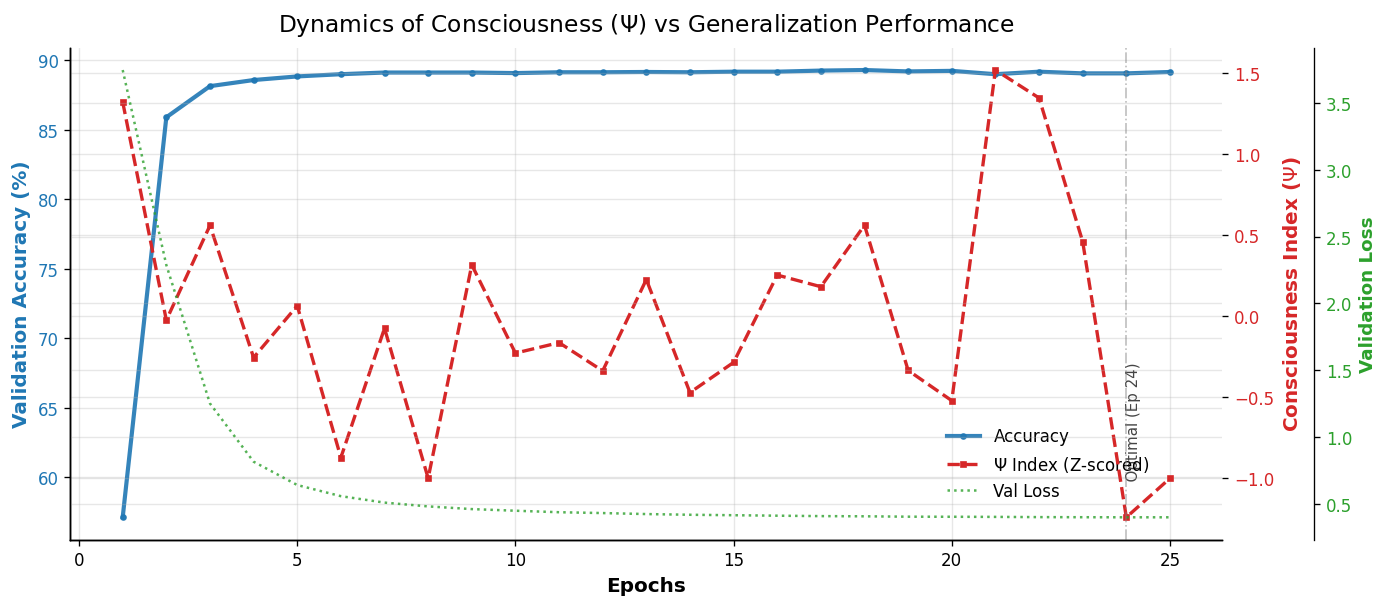

In [16]:
if __name__ == "__main__":
    print("🔄 BẮT ĐẦU BLOCK 8: HUẤN LUYỆN TIẾP NỐI (ViT PRE-TRAINED)")
    
    # --- CẤU HÌNH CHO GIAI ĐOẠN 2 ---
    ADDITIONAL_EPOCHS = 10     # Số epoch bạn muốn chạy thêm (ví dụ: 10)
    LR_RESUME = 1e-4           # Giữ nguyên LR cố định giống y hệt Block 7
    PATIENCE = 7
    
    checkpoint_path = 'best_vit_pretrained.pt'
    csv_path = 'final_results_vit_pretrained.csv'
    
    # 1. KHÔI PHỤC LỊCH SỬ TỪ FILE CSV CŨ
    history = []
    start_epoch = 0
    best_old_val_loss = float('inf')
    
    if os.path.exists(csv_path):
        old_df = pd.read_csv(csv_path)
        for _, row in old_df.iterrows():
            history.append({
                "epoch": int(row["epoch"]),
                "train_loss": float(row["train_loss"]),
                "val_loss": float(row["val_loss"]),
                "val_acc": float(row["val_acc"]),
                "Heff": float(row["Heff"]),
                "M": float(row["M"]),
                "H_raw": float(row.get("H_raw", 0.5))
            })
        start_epoch = int(old_df["epoch"].max())
        best_old_val_loss = old_df["val_loss"].min()
        print(f"✅ Đã tải thành công lịch sử cũ: {start_epoch} epochs.")
    else:
        print("⚠️ Không tìm thấy file CSV cũ. Sẽ chỉ ghi nhận từ Epoch hiện tại.")

    # Đảm bảo Dataset đã được nạp (Sử dụng lại loaders từ Block 7)
    try:
        trainloader
    except NameError:
        print("⚠️ Đang nạp lại Dataset Loaders...")
        IMAGENET_PATH = "/tmp/imagenet-fast" # Hoặc đường dẫn Kaggle của bạn
        trainloader, valloader, NUM_CLASSES = get_imagenet_loaders(IMAGENET_PATH, 256, 256)

    # 2. KHỞI TẠO MODEL VÀ NẠP TRỌNG SỐ
    model = get_vit_classifier(num_classes=NUM_CLASSES).to(DEVICE)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        print(f"✅ Đã nạp thành công bộ não ViT xuất sắc nhất từ: {checkpoint_path}")
    else:
        print("⚠️ CẢNH BÁO: Không tìm thấy file trọng số, mô hình sẽ học lại từ đầu!")

    # 3. SETUP OPTIMIZER CHUẨN SGD CỐ ĐỊNH (KHÔNG SCHEDULER)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR_RESUME, momentum=0.9, weight_decay=1e-4) 
    
    # Kế thừa mức Val Loss tốt nhất để EarlyStopping không bị đếm lại từ đầu
    early_stopping = EarlyStopping(patience=PATIENCE, path=checkpoint_path)
    if best_old_val_loss != float('inf'):
        early_stopping.best_score = -best_old_val_loss
        early_stopping.val_loss_min = best_old_val_loss

    scaler = torch.amp.GradScaler('cuda')
    activations = setup_vit_hooks(model)

    print(f"\n🚀 TIẾP TỤC TRAIN TỪ EPOCH {start_epoch + 1} ĐẾN {start_epoch + ADDITIONAL_EPOCHS}...")

    # 4. VÒNG LẶP HUẤN LUYỆN
    for epoch in range(start_epoch, start_epoch + ADDITIONAL_EPOCHS):
        current_ep = epoch + 1
        
        # --- TRAIN ---
        model.train()
        train_loss, correct, total = 0, 0, 0
        
        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True) 
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            if (batch_idx + 1) % 20 == 0:
                print(f"   [Epoch {current_ep}] Đang xử lý Train Batch {batch_idx+1}/{len(trainloader)}...")
        
        avg_train_loss = train_loss / len(trainloader)
        train_acc = 100. * correct / total

        # --- VALIDATE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for inputs, targets in valloader: 
                inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        avg_val_loss = val_loss / len(valloader)
        val_acc = 100. * val_correct / val_total

        # --- TÍNH PSI ĐA TẦNG ---
        data_iter = iter(valloader)
        inputs_psi, targets_psi = next(data_iter)
        inputs_psi = inputs_psi.to(DEVICE)
        
        with torch.no_grad():
            with torch.amp.autocast(device_type='cuda'): _ = model(inputs_psi) 
        
        multiscale_matrix = gather_multiscale_activations(activations, samples_per_layer=32)
        cnn_signals = prepare_cnn_activations(multiscale_matrix, targets_psi.cpu().numpy(), smooth_window=5)
        metrics = compute_raw_metrics(cnn_signals)

        log = {
            "epoch": current_ep, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
            "val_acc": val_acc, "Heff": metrics["Heff"], "M": metrics["M"], "H_raw": metrics["H_raw"] 
        }
        history.append(log)
        print(f"Ep {current_ep:03d} | Train Acc: {train_acc:.2f}% | Val Loss:{avg_val_loss:.3f} | Val Acc:{val_acc:.2f}% | Heff:{metrics['Heff']:.2f} | M:{metrics['M']:.3f} | LR:{optimizer.param_groups[0]['lr']:.6f}")

        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"🛑 Early stopping triggered at epoch {current_ep}")
            break

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # 5. TỔNG HỢP VÀ VẼ LẠI BIỂU ĐỒ (Bao gồm cả 5 epoch cũ và các epoch mới)
    print("\n✅ Training Finished. Calculating Standardized Psi (Z-score) for ALL epochs...")
    df_results = summarize_experiment_results(history) 

    print("\n" + "="*60)
    # In toàn bộ lịch sử
    for _, row in df_results.iterrows():
        print(f"Epoch {int(row['epoch']):<3d} | Acc: {row['val_acc']:<6.2f} | Hz: {row['Hz']:<6.3f} | Mz: {row['Mz']:<6.3f} | Psi: {row['Psi']:<7.4f}")
              
    # Ghi đè file CSV để lưu lại toàn bộ lịch sử nối dài
    df_results.to_csv(csv_path, index=False)
    
    # Vẽ biểu đồ tổng kết liền mạch
    plot_final_report(df_results)

🔄 BẮT ĐẦU BLOCK 8: HUẤN LUYỆN TIẾP NỐI (ViT PRE-TRAINED)
✅ Đã tải thành công lịch sử cũ: 25 epochs.
Khởi tạo Vision Transformer (ViT-Base-16) với TRỌNG SỐ PRE-TRAIN...
✅ Đã nạp thành công bộ não ViT xuất sắc nhất từ: best_vit_pretrained.pt

🚀 TIẾP TỤC TRAIN TỪ EPOCH 26 ĐẾN 30...
   [Epoch 26] Đang xử lý Train Batch 20/508...
   [Epoch 26] Đang xử lý Train Batch 40/508...
   [Epoch 26] Đang xử lý Train Batch 60/508...
   [Epoch 26] Đang xử lý Train Batch 80/508...
   [Epoch 26] Đang xử lý Train Batch 100/508...
   [Epoch 26] Đang xử lý Train Batch 120/508...
   [Epoch 26] Đang xử lý Train Batch 140/508...
   [Epoch 26] Đang xử lý Train Batch 160/508...
   [Epoch 26] Đang xử lý Train Batch 180/508...
   [Epoch 26] Đang xử lý Train Batch 200/508...
   [Epoch 26] Đang xử lý Train Batch 220/508...
   [Epoch 26] Đang xử lý Train Batch 240/508...
   [Epoch 26] Đang xử lý Train Batch 260/508...
   [Epoch 26] Đang xử lý Train Batch 280/508...
   [Epoch 26] Đang xử lý Train Batch 300/508...
   [

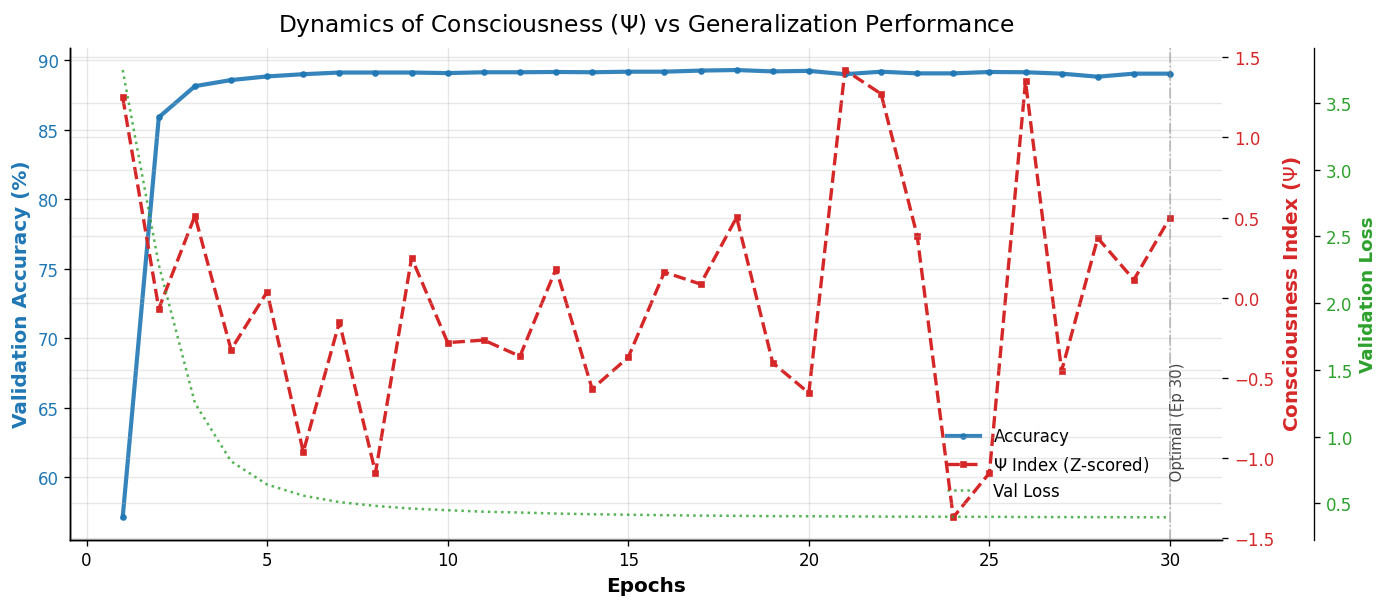

In [17]:
if __name__ == "__main__":
    print("🔄 BẮT ĐẦU BLOCK 8: HUẤN LUYỆN TIẾP NỐI (ViT PRE-TRAINED)")
    
    # --- CẤU HÌNH CHO GIAI ĐOẠN 2 ---
    ADDITIONAL_EPOCHS = 5     # Số epoch bạn muốn chạy thêm (ví dụ: 10)
    LR_RESUME = 1e-4           # Giữ nguyên LR cố định giống y hệt Block 7
    PATIENCE = 7
    
    checkpoint_path = 'best_vit_pretrained.pt'
    csv_path = 'final_results_vit_pretrained.csv'
    
    # 1. KHÔI PHỤC LỊCH SỬ TỪ FILE CSV CŨ
    history = []
    start_epoch = 0
    best_old_val_loss = float('inf')
    
    if os.path.exists(csv_path):
        old_df = pd.read_csv(csv_path)
        for _, row in old_df.iterrows():
            history.append({
                "epoch": int(row["epoch"]),
                "train_loss": float(row["train_loss"]),
                "val_loss": float(row["val_loss"]),
                "val_acc": float(row["val_acc"]),
                "Heff": float(row["Heff"]),
                "M": float(row["M"]),
                "H_raw": float(row.get("H_raw", 0.5))
            })
        start_epoch = int(old_df["epoch"].max())
        best_old_val_loss = old_df["val_loss"].min()
        print(f"✅ Đã tải thành công lịch sử cũ: {start_epoch} epochs.")
    else:
        print("⚠️ Không tìm thấy file CSV cũ. Sẽ chỉ ghi nhận từ Epoch hiện tại.")

    # Đảm bảo Dataset đã được nạp (Sử dụng lại loaders từ Block 7)
    try:
        trainloader
    except NameError:
        print("⚠️ Đang nạp lại Dataset Loaders...")
        IMAGENET_PATH = "/tmp/imagenet-fast" # Hoặc đường dẫn Kaggle của bạn
        trainloader, valloader, NUM_CLASSES = get_imagenet_loaders(IMAGENET_PATH, 256, 256)

    # 2. KHỞI TẠO MODEL VÀ NẠP TRỌNG SỐ
    model = get_vit_classifier(num_classes=NUM_CLASSES).to(DEVICE)
    if os.path.exists(checkpoint_path):
        model.load_state_dict(torch.load(checkpoint_path, map_location=DEVICE))
        print(f"✅ Đã nạp thành công bộ não ViT xuất sắc nhất từ: {checkpoint_path}")
    else:
        print("⚠️ CẢNH BÁO: Không tìm thấy file trọng số, mô hình sẽ học lại từ đầu!")

    # 3. SETUP OPTIMIZER CHUẨN SGD CỐ ĐỊNH (KHÔNG SCHEDULER)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(model.parameters(), lr=LR_RESUME, momentum=0.9, weight_decay=1e-4) 
    
    # Kế thừa mức Val Loss tốt nhất để EarlyStopping không bị đếm lại từ đầu
    early_stopping = EarlyStopping(patience=PATIENCE, path=checkpoint_path)
    if best_old_val_loss != float('inf'):
        early_stopping.best_score = -best_old_val_loss
        early_stopping.val_loss_min = best_old_val_loss

    scaler = torch.amp.GradScaler('cuda')
    activations = setup_vit_hooks(model)

    print(f"\n🚀 TIẾP TỤC TRAIN TỪ EPOCH {start_epoch + 1} ĐẾN {start_epoch + ADDITIONAL_EPOCHS}...")

    # 4. VÒNG LẶP HUẤN LUYỆN
    for epoch in range(start_epoch, start_epoch + ADDITIONAL_EPOCHS):
        current_ep = epoch + 1
        
        # --- TRAIN ---
        model.train()
        train_loss, correct, total = 0, 0, 0
        
        for batch_idx, (inputs, targets) in enumerate(trainloader):
            inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True) 
            optimizer.zero_grad()
            
            with torch.amp.autocast(device_type='cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, targets)
            
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            train_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
            
            if (batch_idx + 1) % 20 == 0:
                print(f"   [Epoch {current_ep}] Đang xử lý Train Batch {batch_idx+1}/{len(trainloader)}...")
        
        avg_train_loss = train_loss / len(trainloader)
        train_acc = 100. * correct / total

        # --- VALIDATE ---
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for inputs, targets in valloader: 
                inputs, targets = inputs.to(DEVICE, non_blocking=True), targets.to(DEVICE, non_blocking=True)
                with torch.amp.autocast(device_type='cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, targets)
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_total += targets.size(0)
                val_correct += predicted.eq(targets).sum().item()
        
        avg_val_loss = val_loss / len(valloader)
        val_acc = 100. * val_correct / val_total

        # --- TÍNH PSI ĐA TẦNG ---
        data_iter = iter(valloader)
        inputs_psi, targets_psi = next(data_iter)
        inputs_psi = inputs_psi.to(DEVICE)
        
        with torch.no_grad():
            with torch.amp.autocast(device_type='cuda'): _ = model(inputs_psi) 
        
        multiscale_matrix = gather_multiscale_activations(activations, samples_per_layer=32)
        cnn_signals = prepare_cnn_activations(multiscale_matrix, targets_psi.cpu().numpy(), smooth_window=5)
        metrics = compute_raw_metrics(cnn_signals)

        log = {
            "epoch": current_ep, "train_loss": avg_train_loss, "val_loss": avg_val_loss,
            "val_acc": val_acc, "Heff": metrics["Heff"], "M": metrics["M"], "H_raw": metrics["H_raw"] 
        }
        history.append(log)
        print(f"Ep {current_ep:03d} | Train Acc: {train_acc:.2f}% | Val Loss:{avg_val_loss:.3f} | Val Acc:{val_acc:.2f}% | Heff:{metrics['Heff']:.2f} | M:{metrics['M']:.3f} | LR:{optimizer.param_groups[0]['lr']:.6f}")

        early_stopping(avg_val_loss, model)
        if early_stopping.early_stop:
            print(f"🛑 Early stopping triggered at epoch {current_ep}")
            break

        gc.collect()
        if torch.cuda.is_available(): torch.cuda.empty_cache()

    # 5. TỔNG HỢP VÀ VẼ LẠI BIỂU ĐỒ (Bao gồm cả 5 epoch cũ và các epoch mới)
    print("\n✅ Training Finished. Calculating Standardized Psi (Z-score) for ALL epochs...")
    df_results = summarize_experiment_results(history) 

    print("\n" + "="*60)
    # In toàn bộ lịch sử
    for _, row in df_results.iterrows():
        print(f"Epoch {int(row['epoch']):<3d} | Acc: {row['val_acc']:<6.2f} | Hz: {row['Hz']:<6.3f} | Mz: {row['Mz']:<6.3f} | Psi: {row['Psi']:<7.4f}")
              
    # Ghi đè file CSV để lưu lại toàn bộ lịch sử nối dài
    df_results.to_csv(csv_path, index=False)
    
    # Vẽ biểu đồ tổng kết liền mạch
    plot_final_report(df_results)